# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

Dataset menggunakan Recipe Reviews and User Feedback
(https://archive.ics.uci.edu/dataset/911/recipe+reviews+and+user+feedback+dataset)


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn joblib

  Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp312-cp312-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.1.1-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   -------

In [24]:
import logging
import re
import string
import warnings
from pathlib import Path
import os
import joblib 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.feature_extraction.text import TfidfVectorizer

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)
warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (10, 6)

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

Additional Variable Information

1. recipe name: {name of the recipe the comment was posted on}
2. recipe number: {placement of the recipe on the top 100 recipes list}
3. recipe code: {unique id of the recipe used by the site}
4. comment id: {unique id of the comment}
5. user id: {unique id of the user who left the comment}
6. user name: {name of the user}
7. user reputation: {internal score of the site, roughly quantifying the past behavior of the user}
8. create at: {time at which the comment was posted as a Unix timestamp}
9. reply count: {number of replies to the comment}
10. thumbs up: {number of up-votes the comment has received}
11. thumbs down: {number of down-votes the comment has received}
12. stars: {the score on a 1 to 5 scale that the user gave to the recipe. A score of 0 means that no score was given}
13. best score: {score of the comment, likely used by the site the help determine the order in the comments that appear in}
14. text: {the text content of the comment}

In [12]:
# 1. LOAD RAW DATASET
BASE_DIR = Path(r"D:\Projects\SMSML_Mochammad Rafly Herdianto\Eksperimen_SML_Moch Rafly Herdianto")
RAW_DATA_PATH = BASE_DIR / "recipereviews_raw" / "Recipe Reviews and User Feedback Dataset.csv"
logger.info(f"Memulai proses pemuatan dataset mentah dari: {RAW_DATA_PATH.name}...")
try:
    # Proses Load Data menggunakan Pandas
    df = pd.read_csv(RAW_DATA_PATH)
    logger.info(f"SUKSES! Dataset berhasil di-load. Dimensi awal (baris, kolom): {df.shape}")
    
except FileNotFoundError:
    logger.error(f"GAGAL: Dataset tidak ditemukan di alamat -> {RAW_DATA_PATH}. Pastikan path benar.")

# Menghapus kolom sisa index (Unnamed: 0) jika kolom tersebut ada
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    df_clean = df_clean.drop(columns=['Unnamed: 0'], errors='ignore')
    logger.info("Kolom 'Unnamed: 0' berhasil dihapus!")

# 2. REVIEW BASIC DATA (EDA Dasar)

# Mengecek 5 data terbawah & teratas
display(df.head())
print("\n" + "="*50)
print("INFORMASI TIPE DATA & NILAI KOSONG (MISSING VALUES):")
print("="*50)
df.info()

2026-04-02 06:58:30,055 - INFO - Memulai proses pemuatan dataset mentah dari: Recipe Reviews and User Feedback Dataset.csv...
2026-04-02 06:58:30,167 - INFO - SUKSES! Dataset berhasil di-load. Dimensi awal (baris, kolom): (18182, 15)
2026-04-02 06:58:30,168 - INFO - Kolom 'Unnamed: 0' berhasil dihapus!


,recipe_number,recipe_code,recipe_name,comment_id,user_id,user_name,user_reputation,created_at,reply_count,thumbs_up,thumbs_down,stars,best_score,text
0,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2G3aneMRgRMZwXqIHmSdXSG1hEM,u_9iFLIhMa8QaG,Jeri326,1,1665619889,0,0,0,5,527,"I tweaked it a little, removed onions because ..."
1,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2FsPC83HtzCsQAtOxlbL6RcaPbY,u_Lu6p25tmE77j,Mark467,50,1665277687,0,7,0,5,724,Bush used to have a white chili bean and it ma...
2,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2FPrSGyTv7PQkZq37j92r9mYGkP,u_s0LwgpZ8Jsqq,Barbara566,10,1664404557,0,3,0,5,710,I have a very complicated white chicken chili ...
3,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2DzdSIgV9qNiuBaLoZ7JQaartoC,u_fqrybAdYjgjG,jeansch123,1,1661787808,2,2,0,0,581,"In your introduction, you mentioned cream chee..."
4,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2DtZJuRQYeTFwXBoZRfRhBPEXjI,u_XXWKwVhKZD69,camper77,10,1664913823,1,7,0,0,820,Wonderful! I made this for a &#34;Chili/Stew&#...



INFORMASI TIPE DATA & NILAI KOSONG (MISSING VALUES):
<class 'pandas.DataFrame'>
RangeIndex: 18182 entries, 0 to 18181
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   recipe_number    18182 non-null  int64
 1   recipe_code      18182 non-null  int64
 2   recipe_name      18182 non-null  str  
 3   comment_id       18182 non-null  str  
 4   user_id          18182 non-null  str  
 5   user_name        18182 non-null  str  
 6   user_reputation  18182 non-null  int64
 7   created_at       18182 non-null  int64
 8   reply_count      18182 non-null  int64
 9   thumbs_up        18182 non-null  int64
 10  thumbs_down      18182 non-null  int64
 11  stars            18182 non-null  int64
 12  best_score       18182 non-null  int64
 13  text             18180 non-null  str  
dtypes: int64(9), str(5)
memory usage: 1.9 MB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

2026-04-02 06:58:50,773 - INFO - ===== 1. PROFILING AWAL (SEBELUM CLEANING) =====
2026-04-02 06:58:50,790 - INFO - Jumlah baris salinan identik (Duplikat): 0
2026-04-02 06:58:50,796 - INFO - Kolom yang memiliki nilai kosong (NaN):
text    2


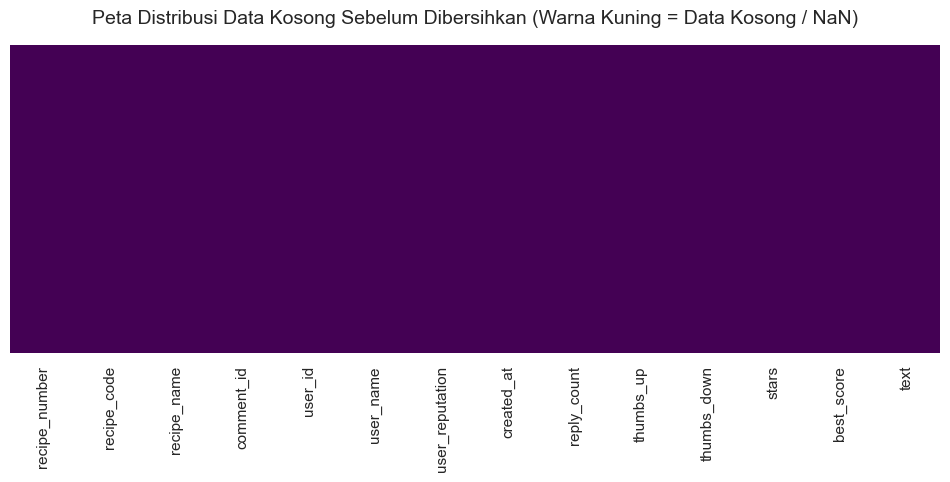

In [13]:
# ==============================================================================
# 1. PROFILING MISSING VALUES & DUPLIKAT (SEBELUM CLEANING)
# ==============================================================================
logger.info("===== 1. PROFILING AWAL (SEBELUM CLEANING) =====")

# Cek Duplikat Awal
jumlah_duplikat = df.duplicated().sum()
logger.info(f"Jumlah baris salinan identik (Duplikat): {jumlah_duplikat}")

# Cek Missing Values Awal
jumlah_missing = df.isnull().sum()
if jumlah_missing.sum() > 0:
    logger.info(f"Kolom yang memiliki nilai kosong (NaN):\n{jumlah_missing[jumlah_missing > 0].to_string()}")
else:
    logger.info("LUAR BIASA: Tidak ada nilai kosong di dataset Anda.")

# Tampilkan Peta Visualisasi (Heatmap) mana bagian data yang warnanya kosong
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Peta Distribusi Data Kosong Sebelum Dibersihkan (Warna Kuning = Data Kosong / NaN)', fontsize=14, pad=15)
plt.show()

In [16]:
# ==============================================================================
# 2. PROSES CLEANING (PENGHAPUSAN DAN IMPUTASI)
# ==============================================================================
logger.info("===== 2. MELAKUKAN PENGHAPUSAN DATA KOTOR =====")

# A. Menghapus Data Duplikat (Baris yang ter-input ganda)
df_clean = df.drop_duplicates()

# B. Menangani Nilai Kosong (Missing Values)
# - Jika kolom teks sentimen (review) kosong, wajib dihapus
kolom_vital_wajib = ['text', 'stars', 'user id'] 
if set(kolom_vital_wajib).issubset(df_clean.columns):
    df_clean = df_clean.dropna(subset=kolom_vital_wajib)

# - Namun jika interaksi angka (seperti thumbs up/down, reply) kosong, asumsikan itu berarti "0 interaksi"
kolom_angka_interaksi = ['thumbs up', 'thumbs down', 'reply count', 'user reputation']
for col in kolom_angka_interaksi:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

logger.info(f"Pembersihan Selesai! Dimensi awal: {len(df)} baris -> Bersih: {len(df_clean)} baris")
logger.info(f"Total baris bermasalah hasil drop: {len(df) - len(df_clean)}")

2026-04-02 07:01:09,389 - INFO - ===== 2. MELAKUKAN PENGHAPUSAN DATA KOTOR =====
2026-04-02 07:01:09,406 - INFO - Pembersihan Selesai! Dimensi awal: 18182 baris -> Bersih: 18182 baris
2026-04-02 07:01:09,406 - INFO - Total baris bermasalah hasil drop: 0


2026-04-02 07:01:21,621 - INFO - ===== 3. MEMBUAT GRAFIK EXPLORATORY DATA ANALYSIS =====
2026-04-02 07:01:21,644 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-02 07:01:21,652 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-02 07:01:21,689 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-02 07:01:21,697 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


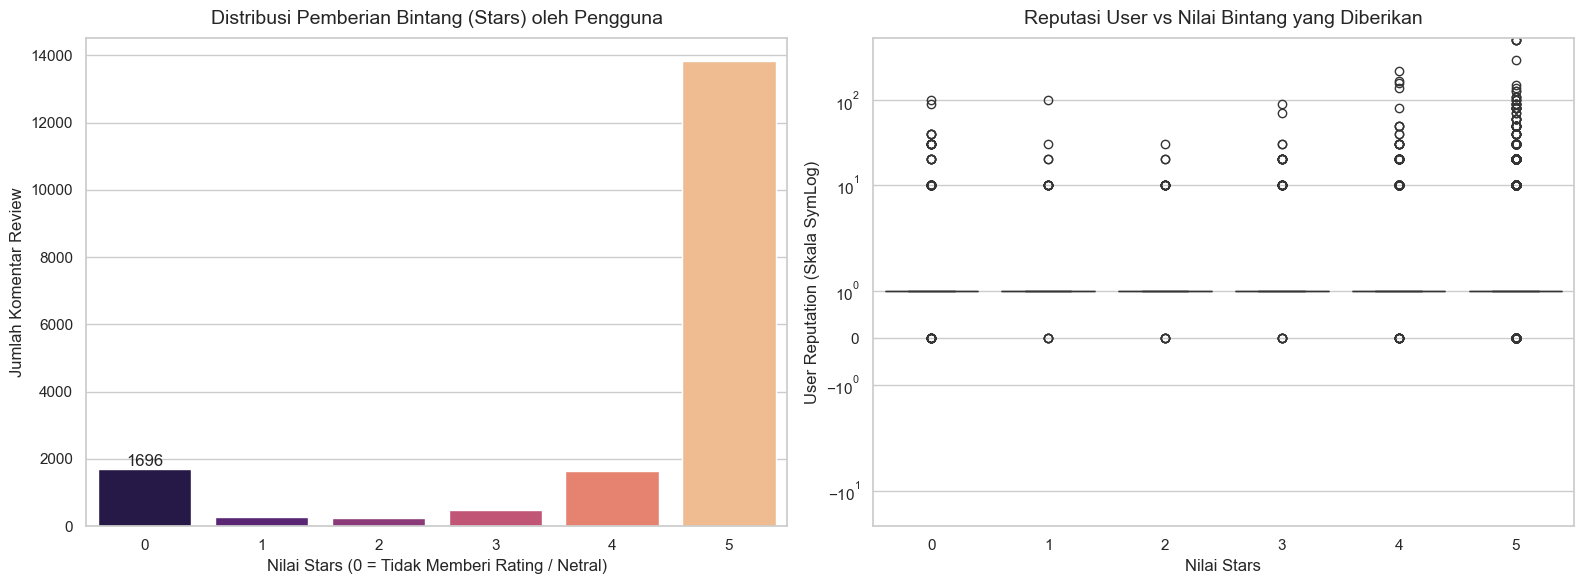

In [17]:
# ==============================================================================
# 3. GRAFIK EDA (MENELITI KARAKTER USER PADA DATA BERSIH)
# ==============================================================================
logger.info("===== 3. MEMBUAT GRAFIK EXPLORATORY DATA ANALYSIS =====")

# Kita buat 2 grafik bersebelahan (1 Baris, 2 Kolom)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grafik Kiri: Melihat kecenderungan pengguna dalam memberikan Bintang (Stars)
sns.countplot(data=df_clean, x='stars', palette='magma', ax=axes[0])
axes[0].set_title('Distribusi Pemberian Bintang (Stars) oleh Pengguna', fontsize=14, pad=10)
axes[0].set_xlabel('Nilai Stars (0 = Tidak Memberi Rating / Netral)')
axes[0].set_ylabel('Jumlah Komentar Review')
axes[0].bar_label(axes[0].containers[0]) # Menampilkan angka pastinya di atas tiap batang (bar)

# Grafik Kanan: Apakah pengguna bereputasi tinggi cenderung lebih pemilih?
nama_kolom_reputasi = 'user_reputation'
try:
    sns.boxplot(data=df_clean, x='stars', y=nama_kolom_reputasi, palette='viridis', ax=axes[1])
    
    axes[1].set_yscale('symlog') 
    
    axes[1].set_title('Reputasi User vs Nilai Bintang yang Diberikan', fontsize=14, pad=10)
    axes[1].set_xlabel('Nilai Stars')
    axes[1].set_ylabel('User Reputation (Skala SymLog)')
except KeyError:
    # Jika grafik kanan tetap tidak muncul, terminal sel ini akan berteriak memberitahu Anda nama yang benar!
    logger.error(f"GRAFIK KANAN GAGAL: Tidak ada kolom bernama '{nama_kolom_reputasi}'. Silakan cek ulang ejaan dari hasil df.info()")
plt.tight_layout()
plt.show()

## Interpretasi Analisis Data Eksploratif (EDA)

1. Analisis Distribusi Kelas Penilaian (Grafik Kiri: Target Imbalance)
Berdasarkan bagan batang (countplot) mengenai distribusi pemberian bintang, dapat ditarik konklusi statistik sebagai berikut:

    - Asimetri Populasi Ekstrem (Highly Imbalanced Data): Mayoritas absolut observasi terpusat secara eksponensial pada kategori bintang 5 (melampaui 13.000 ulasan), sedangkan kelas minoritas (bintang 1, 2, dan 3) memiliki frekuensi data yang sangat marjinal. Selain itu, anomali penilaian nol (0) menduduki interaksi kedua tertinggi di luar kelas dominan.
    - Indikasi Bias Perilaku (Behavioral Bias): Fenomena ketidakseimbangan ini merepresentasikan wujud positive confirmation bias dalam demografi ekosistem situs web tersebut. Secara analitik, terdapat tendensi di mana pengguna hanya memiliki motivasi intrinsik untuk berpartisipasi mengunggah ulasan apabila mereka memiliki afirmasi kepuasan maksimal terhadap suatu resep.
    - Saran Pemodelan: Tingkat ketidakseimbangan (class imbalance) yang signifikan ini memperingatkan perlunya mitigasi khusus pada tahap Preprocessing. Rekomendasi intervensi secara metodologis adalah melakukan agregasi pelabelan ulang (re-grouping label), yakni mereduksi kelas bintang menjadi polaritas biner ("Sentimen Positif", "Netral", dan "Sentimen Negatif") guna mengerem kecenderungan model Machine Learning untuk overfitting atau bias saat memprediksi kelas mayoritas.

2. Analisis Bivariat Reputasi Terhadap Penilaian (Grafik Kanan: Near-Zero Variance)
Berdasarkan diagram kotak garis (boxplot) bersumbu logaritma simetris (SymLog), interpretasi relasional membuktikan penemuan matematis berikut:

    - Penyusutan Rentang Interkuartil (IQR Collapse): Bentuk anatomi boxplot pada tiap entitas sumbu absis (0 hingga 5) tidak berekspansi membentuk blok persegi, melainkan terkompresi secara sempurna menjadi garis ekuivalen horizontal yang bermuara pada titik ordinat $10^0$ (bernilai 1). Indikator ini membuktikan bahwa persentil ke-25 hingga persentil ke-75 dari populasi memiliki skor deterministik berupa angka persis 1.
    - Ketiadaan Korelasi yang Signifikan (Lack of Predictive Value): Eksistensi nilai outliers yang merujuk pada pengguna dengan utilitas tinggi (dengan ordinat $>10^1$ hingga $>10^2$) mendistribusikan dirinya pada seluruh variabel penilai, dengan konsentrasi tertinggi pada bintang 5. Hal ini menerangkan nihilnya segregasi perilaku antara pengguna amatir dan pengguna bermanuver tinggi; kredibilitas (reputation) secara statistik tidak mempunyai pengaruh independen terhadap kekritisan penilaian (stars).
    - Saran Pemodelan: Atribut user_reputation mengalami kasus varians mendekati tak-bernilai (near-zero variance). Pemertahanan atribut ini di dalam fase konstruksi algoritma klasifikasi dapat berpotensi menjadi prediktor yang cacat dan redundan (weak variable), sehingga eliminasi fitur (feature reduction) lazim dilakukan pada kerangka kerja sistem untuk mengurangi latensi beban komputasi.

2026-04-02 07:10:04,646 - INFO - ===== MEMBUAT PETA KORELASI SELURUH FITUR NUMERIK =====


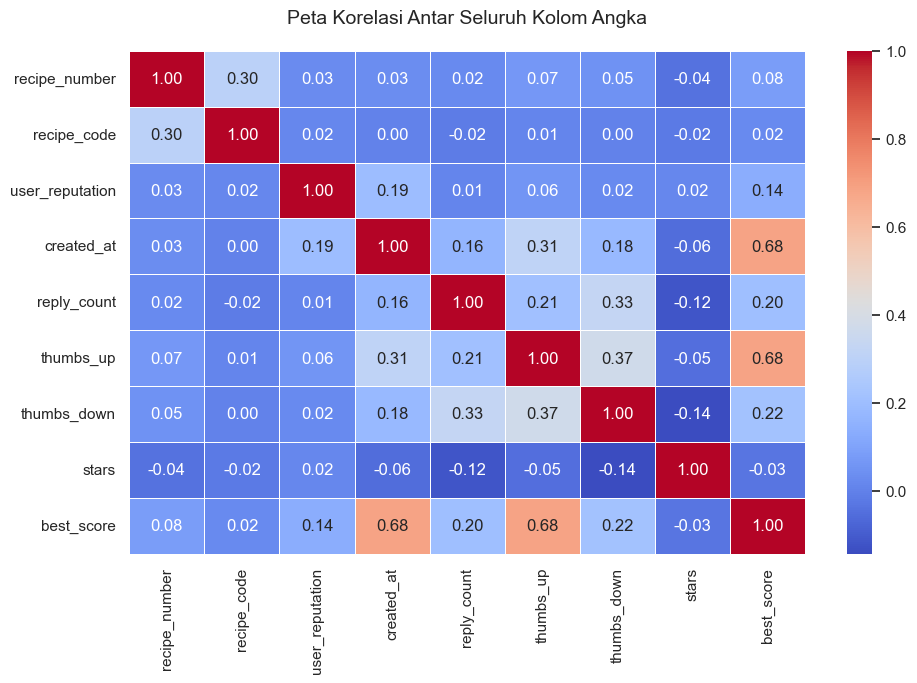

In [18]:
# ====================
# 3B. GRAFIK KORELASI
# ====================
logger.info("===== MEMBUAT PETA KORELASI SELURUH FITUR NUMERIK =====")
# 1. Menyaring otomatis HANYA kolom yang memiliki nilai berupa Angka (Numerik)
# (Mengabaikan kolom teks secara otomatis agar tidak error)
kolom_angka_df = df_clean.select_dtypes(include=[np.number])

# 2. Menggambar Heatmap Korelasi
plt.figure(figsize=(10, 7))

matriks_korelasi = kolom_angka_df.corr()
# Tampilkan ke dalam bentuk Heatmap membelah warna Merah (Positif) dan Biru (Negatif)
sns.heatmap(matriks_korelasi, 
            annot=True,             
            cmap='coolwarm',         
            fmt=".2f",               
            linewidths=0.5)
plt.title('Peta Korelasi Antar Seluruh Kolom Angka', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

## Interpretasi Peta Korelasi Matriks (Analisis Multivariat)

Visualisasi berbasis matriks korelasi di atas mengukur derajat hubungan linear antar-variabel kuantitatif menggunakan metrik Pearson Correlation Coefficient (rentang nilai $-1.00$ hingga $1.00$). Berdasarkan pemetaan intensitas warna dan ekuivalensi matematisnya, dapat ditarik beberapa postulat analitik krusial mengenai struktur dataset:

1. Mekanisme Determinasi Skor Terbaik (Strong Positive Correlation). 
Terdapat korelasi positif yang paling solid (bernilai ekuivalen $r = 0.68$) pada dua persimpangan variabel kritis terhadap best_score:

    - Korelasi best_score dan thumbs_up ($r = 0.68$): Hal ini mengonfirmasi hipotesis bahwa algoritma situs web merumuskan Best Score secara asimetris dengan memprioritaskan dukungan absolut (community endorsement). Semakin banyak pengguna lain yang menyetujui ulasan tersebut (jempol ke atas), semakin eksponensial nilai skor kelayakannya.
    - Korelasi best_score dan created_at ($r = 0.68$): Karena variabel created_at diformat pada basis Unix Timestamp (di mana angka membesar jika waktu semakin baru), korelasi positif ini menyingkap eksistensi Bias Kebaruan (Recency Bias) pada algoritma internal website. Ulasan yang lebih segar (baru di- posting) mendapatkan injeksi bobot lebih tinggi pada struktur best_score, mencegah daftar ulasan teratas didominasi oleh ulasan-ulasan usang bertahun-tahun lalu yang mengumpulkan thumbs up tinggi secara organik dari waktu ke waktu.

2. Kausalitas Interaksi Sentimen dan Diskusi (Moderate Correlation).
Fenomena sentimen kontroversial terekam jelas pada metrik interaksi kolom komentar:

    - Variabel intensitas reply_count mendemonstrasikan korelasi positif yang lebih tinggi terhadap thumbs_down ($r = 0.33$) dibandingkan korelasi terhadap thumbs_up ($r = 0.21$).
    - Implikasi Ilmiah: Dalam studi Perilaku Konsumen (Consumer Behavior), ini membuktikan fenomena pemicu debat. Komentar yang bersifat kontroversial atau berlawanan dengan opini mayoritas publik (sehingga memanen banyak thumbs down) memiliki probabilitas asimtotik yang lebih besar untuk memicu adu argumen (reply diskusi) ketimbang komentar bernada pujian konvensional.

3. Independensi Otonom pada Variabel Target (Lack of Correlation)
    - Variabel stars (Penilaian Bintang) menunjukkan nilai fluktuasi korelasi yang menyentuh level margin kesalahan (mendekati $0.00$) terhadap seluruh kolom fitur lain. Skor relasi terbesarnya hanyalah $-0.14$ (terhadap thumbs_down).
    - Implikasi Ilmiah: Variabel penentu penilaian kualitatif resep (bintang 1-5) bertindak secara sepenuhnya otonom. Interaksi pengguna secara independen merefleksikan bahwa preferensi pemberian bintang murni didasari atas kepuasan subjektivitas pada resep makanan tersebut, tanpa bias terhadap status pengguna (reputasi) maupun usia komentar tersebut dipublikasikan.

4. Implikasi Lanjutan (Recommendation for Modeling)
    - Temuan tingginya korelasi antara best_score, created_at, dan thumbs_up ($r > 0.65$) memunculkan peluang terjadinya Multikolinearitas (Multicollinearity) pada ruang vektor. Disarankan untuk melakukan metode degradasi kelimpahan data seperti PCA (Principal Component Analysis) atau secara asertif menyeleksi salah satu saja dari ketiga fitur tersebut untuk meminimalisasi noise komputasi dalam model kelak.

In [4]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


2026-04-02 07:19:32,576 - INFO - ===== 4. VISUALISASI KATA TERBANYAK (WORD CLOUD) =====
2026-04-02 07:19:32,593 - INFO - Memproses dan me-render WordCloud (Ini mungkin memakan waktu beberapa detik)...


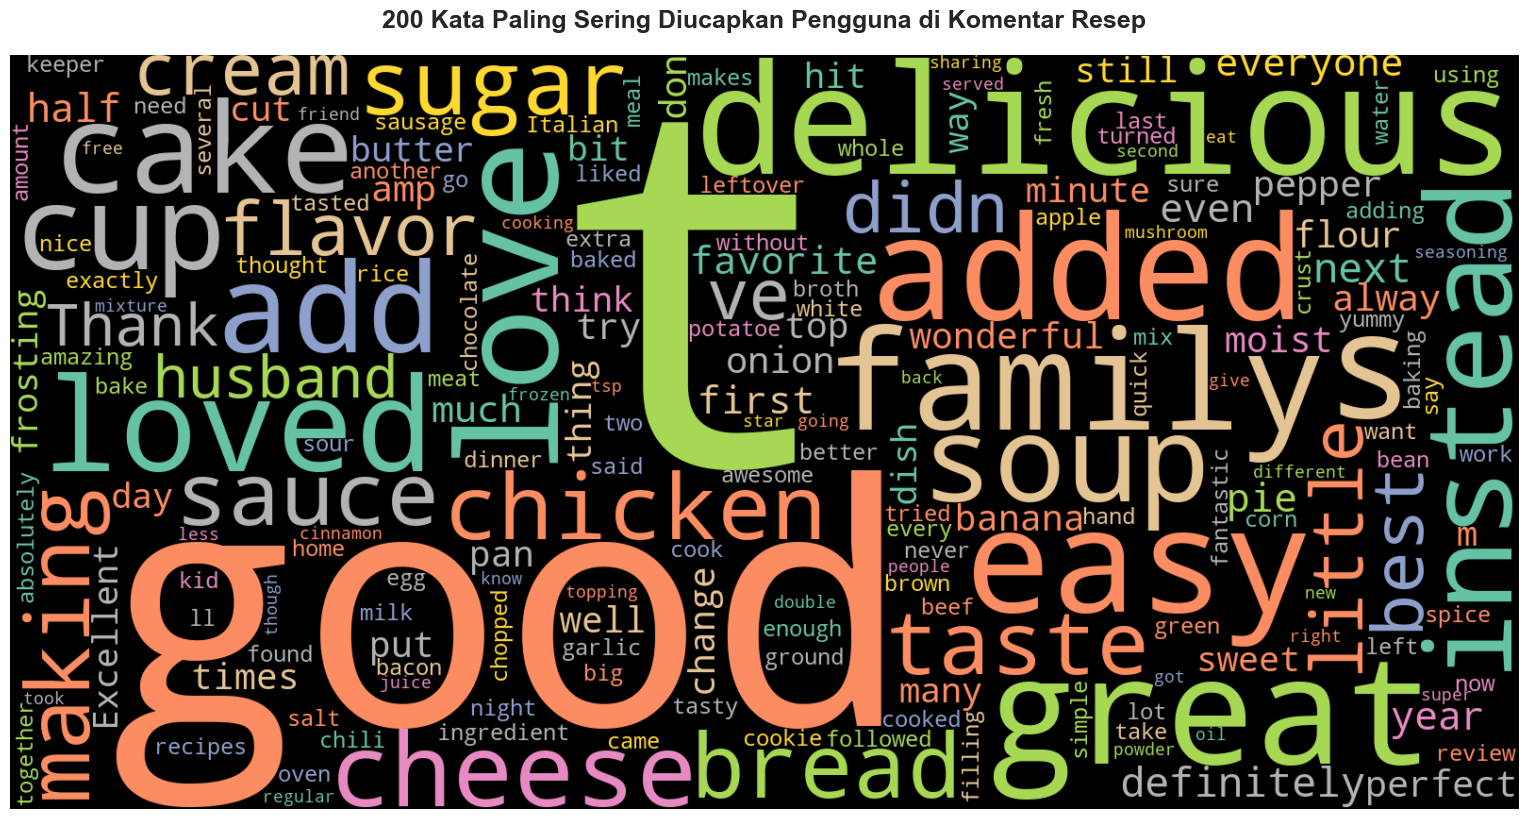

In [20]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# ===============
# 4. WORD CLOUD 
# ===============
logger.info("===== 4. VISUALISASI KATA TERBANYAK (WORD CLOUD) =====")
# 1. Menggabungkan seluruh baris komentar ('text') menjadi satu string (teks) raksasa
# (Mengunakan astype(str) meminimalisir jika ada sisa angka/float yang terlewati dari cleaning)
semua_komentar = " ".join(str(review) for review in df['text'].dropna())

# 2. Memblokir "Kata Sampah Umum" agar WordCloud lebih Bermakna (Sentimen)
kata_sampah = set(STOPWORDS)
kata_sampah_tambahan = ['recipe', 'make', 'made', 'one', 'will', 'use', 'used', 'time', 'really', 'just'] 
kata_sampah.update(kata_sampah_tambahan)
logger.info("Memproses dan me-render WordCloud (Ini mungkin memakan waktu beberapa detik)...")

# 3. Inisialisasi Kanvas WordCloud
wordcloud = WordCloud(
    width=1600, 
    height=800, 
    random_state=42,             
    background_color='black',    
    colormap='Set2',            
    collocations=False,          
    stopwords=kata_sampah,
    max_words=200                
).generate(semua_komentar)

# 4. Plotting dengan Matplotlib
plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear') 
plt.axis('off')                                 
plt.title('200 Kata Paling Sering Diucapkan Pengguna di Komentar Resep', fontsize=18, pad=20, weight='bold')
plt.tight_layout(pad=0)
plt.show()

In [21]:
# Jadikan data bersih ini sebagai df utama untuk proses selanjutnya
df = df_clean.copy()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [25]:
# ===========================
# PERSIAPAN DIREKTORI OUTPUT
# ===========================
OUTPUT_DIR = Path(r"D:\Projects\SMSML_Mochammad Rafly Herdianto\Eksperimen_SML_Moch Rafly Herdianto\preprocessing\recipereviews_preprocessing")
# Membuat foldernya secara otomatis jika belum ada
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
logger.info(f"Siap menyimpan semua hasil produksi ke: {OUTPUT_DIR}")


2026-04-02 07:47:07,187 - INFO - Siap menyimpan semua hasil produksi ke: D:\Projects\SMSML_Mochammad Rafly Herdianto\Eksperimen_SML_Moch Rafly Herdianto\preprocessing\recipereviews_preprocessing


In [26]:
# -------------------------------------------------------------------------
# A. BINNING (TARGET) & FITUR CALENDAR
# -------------------------------------------------------------------------
logger.info("=== A. BINNING TARGET & EKSTRAKSI WAKTU ===")
# 1. Menghalau Bintang 0 (Sesuai dokumentasi awal: Absence of rating)
df_ready = df_clean[df_clean['stars'] != 0].copy()
# 2. Pengelompokan Data (BINNING) Atasi Imbalance -> Biner: Positif (1) & Negatif/Netral (0)
df_ready['sentiment_class'] = df_ready['stars'].apply(lambda x: 1 if x >= 4 else 0)
# 3. Menangani Korelasi Waktu Unix ke Konsep Kalender
if 'created_at' in df_ready.columns:
    df_ready['waktu_baku'] = pd.to_datetime(df_ready['created_at'], unit='s')
df_ready['review_year'] = df_ready['waktu_baku'].dt.year
df_ready['review_month'] = df_ready['waktu_baku'].dt.month
# 4. Eliminasi Noise dan Varians Buruk (Berdasarkan Temuan Boxplot & Heatmap)
kolom_sampah = [
    'user_reputation', 'best_score', 'stars', 'waktu_baku', 
    'created_at', 'comment_id', 'user_id', 
    'recipe_code', 'user_name', 'recipe_name', 'recipe_number'
]
df_ready = df_ready.drop(columns=[col for col in kolom_sampah if col in df_ready.columns])

2026-04-02 07:47:13,574 - INFO - === A. BINNING TARGET & EKSTRAKSI WAKTU ===


In [27]:
# -------------------------------------------------------------------------
# B. PENCEGAHAN DATA LEAKAGE (TRAIN-TEST SPLIT)
# -------------------------------------------------------------------------
logger.info("=== B. SPLIT TEST SET ===")
target = 'sentiment_class'
X = df_ready.drop(columns=[target])
y = df_ready[target]
# Menggunakan Opsi 'stratify' agar rasio sentimen di data Train selaras dengan data Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

2026-04-02 07:47:19,448 - INFO - === B. SPLIT TEST SET ===


In [28]:
# -------------------------------------------------------------------------
# C. PENYERAGAMAN SKALA SEKALIGUS PENANGANAN OUTLIER
# -------------------------------------------------------------------------
logger.info("=== C. MENGGUNAKAN ROBUST SCALER (PENANGANAN OUTLIER) ===")
kolom_numerik_tersisa = X_train.select_dtypes(include=[np.number]).columns.tolist()
# RobustScaler meredam goncangan outlier berdasarkan kuartil, sangat cocok untuk media sosial
scaler = RobustScaler()
# Fit HANYA pada data LATIH agar nilai rata-ratanya tidak bocor ke data UJI
X_train[kolom_numerik_tersisa] = scaler.fit_transform(X_train[kolom_numerik_tersisa])
X_test[kolom_numerik_tersisa]  = scaler.transform(X_test[kolom_numerik_tersisa])
joblib.dump(scaler, OUTPUT_DIR / 'robust_scaler_production.pkl')

2026-04-02 07:47:25,548 - INFO - === C. MENGGUNAKAN ROBUST SCALER (PENANGANAN OUTLIER) ===


['D:\\Projects\\SMSML_Mochammad Rafly Herdianto\\Eksperimen_SML_Moch Rafly Herdianto\\preprocessing\\recipereviews_preprocessing\\robust_scaler_production.pkl']

In [30]:
# -------------------------------------------------------------------------
# D. ENCODING NLP KATEGORIKAL 
# -------------------------------------------------------------------------
logger.info("=== D. ENCODING TEKS BAHASA ALAMI (TF-IDF) ===")
if 'text' in X_train.columns:
    # Mengambil maksimal 1000 kata tersering berbobot, membuang kata tidak relevan pada bahasa Inggris
    tfidf = TfidfVectorizer(max_features=1000, stop_words='english', min_df=5, max_df=0.9)
    
    # Mengubah secara paksa NaN/Kosong menjadi teks/string kosong ("") agar tidak menggagalkan proses ekstraksi matriks
    X_train_text = tfidf.fit_transform(X_train['text'].fillna("")).toarray()
    X_test_text  = tfidf.transform(X_test['text'].fillna("")).toarray()
    
    joblib.dump(tfidf, OUTPUT_DIR / 'tfidf_model_production.pkl')
    
    # Tempel Data Label Kolom Teks ("word_yummy", "word_disgusting") 
    fitur_nlp = [f"kata_{w}" for w in tfidf.get_feature_names_out()]
    df_train_nlp = pd.DataFrame(X_train_text, columns=fitur_nlp, index=X_train.index)
    df_test_nlp  = pd.DataFrame(X_test_text, columns=fitur_nlp, index=X_test.index)
    
    # Menyatukan Matriks NLP dengan Data Kuantitatif yang lain, membuang kolom tulisan 'text'
    X_train = pd.concat([X_train.drop(columns=['text']), df_train_nlp], axis=1)
    X_test  = pd.concat([X_test.drop(columns=['text']), df_test_nlp], axis=1)

2026-04-02 07:49:30,971 - INFO - === D. ENCODING TEKS BAHASA ALAMI (TF-IDF) ===


In [31]:
# ----------------------------
# E. EXPORT KE MATRIKS BERSIH
# ----------------------------
logger.info("=== E. MENYIMPAN HASIL KE DISK ===")

X_train.to_csv(OUTPUT_DIR / 'X_train_ready.csv', index=False)
X_test.to_csv(OUTPUT_DIR / 'X_test_ready.csv', index=False)
y_train.to_csv(OUTPUT_DIR / 'y_train_ready.csv', index=False)
y_test.to_csv(OUTPUT_DIR / 'y_test_ready.csv', index=False)
logger.info(f"Dimensi Final -> Train: {X_train.shape}, Test: {X_test.shape}")

2026-04-02 07:49:40,234 - INFO - === E. MENYIMPAN HASIL KE DISK ===
2026-04-02 07:49:45,909 - INFO - Dimensi Final -> Train: (13188, 1005), Test: (3298, 1005)
